# Polyhedral sparsity for attention — a step-by-step log

A working notebook, kept in **decision order**. Each section records *why* a step
was taken, not only what it produced, so a wrong turn can be re-litigated without
re-deriving the argument. Every number is computed live by the cells below.

**Status: two mechanisms established analytically. Nothing here has touched a GPU.**
All results are exact element counts, validated against brute force. They are a
*proxy* for time, not a measurement of it — see the closing section.

Prose version of the same log: [`docs/NOTES.md`](../docs/NOTES.md).
Everything below imports from `polyattn` (`src/`), so the analysis is testable
(`pytest`, 400 cases) rather than trapped in notebook cells.

## §0 — The original question

The opening ask was *polyhedral sparse optimization for mixture of experts*.
After top-k routing, an MoE FFN is a ragged block-diagonal GEMM:

```
for e in 0..E:            # n_e known only at runtime
  for i in 0..n_e:        # ragged
    y[tok[e,i]] += w[e,i] * FFN_e(x[tok[e,i]])
```

Classical polyhedral compilation needs domains bounded by affine functions of
loop indices and compile-time parameters. `n_e` is a runtime value, so plain
isl/Pluto cannot schedule this at all. Three ways out:

1. **Sparse Polyhedral Framework** (Strout, Hall, Olschanowsky) — admit
   uninterpreted functions (`expert_offset(e)`, `tok(e,i)`); a generated
   *inspector* materialises the index arrays at runtime, an *executor* runs the
   transformed loop.
2. **Union of parametric polyhedra** — each `n_e` a symbolic parameter, schedule
   the union with isl. Simpler; degrades badly once `n_e < tile`.
3. **Capacity-factor padding** — pad to fixed capacity `C`, giving a static
   `[E, C, d]` box. Fully affine, but converts sparsity into predication and
   throws the win away. Baseline only.

## §1 — Why MoE was rejected

**Deciding argument: inspector–executor pays off when the sparsity pattern's
lifetime greatly exceeds the cost of inspecting it. MoE routing changes every
batch.** The histogram / sort / prefix-sum is paid on every forward pass and
amortised over exactly one use. That is the worst case for the entire SPF
tradition, whose canonical wins come from matrices and meshes inspected once and
reused thousands of times.

Two supporting reasons:

- **The sparsity is coarse and dense-within-block.** Each expert's work is a big
  dense GEMM — precisely what a tuned grouped GEMM already captures. Polyhedral
  reasoning is least differentiating exactly where the work is.
- **The baselines are industrial**: MegaBlocks, ScatterMoE, Tutel, plus fused MoE
  kernels in vLLM / SGLang / TensorRT-LLM.

Worth recording: MegaBlocks' histogram + prefix-sum that builds its BCSR block
indices *is* a hand-written inspector. Recasting it as SPF is a legitimate
reframing — it just doesn't buy speed, for the amortisation reason above.

## §2 — The ranking lens, and the domain actually chosen

Generalising §1 into a reusable criterion — score a candidate domain on three axes:

| domain | pattern reuse | variant-space size | baseline slack |
|---|---|---|---|
| MoE | very low (1 batch) | medium | low |
| sparse attention | low–medium | **high** | medium |
| GNN (SpMM / SDDMM) | high | high | low–medium |
| irregular-mesh / sparse solvers | **very high** | high | **high** |

Want high on at least two. MoE is high on none.

Two alternatives are recorded as **live, not discarded**: unstructured-mesh PDE
solvers (best pure fit — the mesh is fixed for the whole run, so the inspector
amortises to nothing; substantial prior art in Strout's sparse tiling and
SLOPE/PyOP2/Firedrake), and mesh-fixed neural surrogates (mesh-like reuse, ML
audience).

**Chosen: programmable sparse attention.** The deciding reason is that unlike
MoE, a large sub-family of attention masks — causal, sliding-window, dilated,
strided, prefix-LM — is a *pure function of position*, hence known at compile
time. No inspector, no amortisation problem: the classical affine regime, where
the tooling is strongest. Document-packing, learned selection and KV eviction
form a separate, clearly-labelled data-dependent tier.

**The incumbent** is PyTorch **FlexAttention**. It accepts an arbitrary
`mask_mod` predicate but prunes at **block** granularity via a precomputed
`BlockMask`. It does distinguish fully-unmasked blocks from partial ones (so it
skips *mask evaluation* on full blocks), but **partial blocks are still computed
in full**. That is the gap under test.

**Threat identified before any experiment:** tensor cores impose a hard
granularity floor — MMA is `m16n8k16`-shaped, so exact iteration pruning is
physically unavailable. The honest ceiling is not "waste eliminated" but "waste
eliminated down to ~16 granularity", and everything below is reported against a
16-aligned oracle rather than a perfect one.

## §3 — Experiment 1: how much does block granularity actually cost?

**Purpose: a cheap kill-test**, with the threshold stated in advance:

> If the gap between the 128×128 lattice and a 32-aligned ragged model is under
> ~15% across the zoo, the idea does not clear the noise floor of kernel tuning
> and the project stops.

Pure counting — no GPU, no kernel, one afternoon.

### The design decision that makes it fair

**One cost function expresses every model we want to compare:**

$$\mathrm{cost}(B_Q, A) = \sum_{\text{row-blocks}} B_Q \cdot A \cdot
\bigl|\{\,A\text{-aligned column segments meeting the block's live set}\,\}\bigr|$$

- `cost(128, 128)` — FlexAttention's BlockMask, *including* its partial-block waste
- `cost(BQ, A)` — polyhedral ragged bounds at tile granularity `(BQ, A)`
- `cost(16, 16)` — the MMA-shaped physical floor, and therefore the real target
- `cost(1, 1)` — the live element count; the unreachable lower bound

Because all three models are the *same function at different granularities*, the
comparison cannot be rigged by modelling the baseline unfavourably.

Covering the union with **A-aligned segments** rather than an interval hull
matters: it keeps the model honest for strided masks, whose per-row live set is
not contiguous. An interval-hull model would have overstated the baseline's waste.

In [1]:
%matplotlib inline
import inspect
import numpy as np

from polyattn import cost, figures, masks, shapes, transforms
from polyattn.experiments import compose, granularity, reindex, sampling

print(inspect.getsource(cost.cost))

def cost(mask, N, BQ, A, exact_only=False):
    """Returns (elements_computed, was_sampled)."""
    assert N % BQ == 0 and N % A == 0
    nblocks = N // BQ
    if nblocks <= MAX_BLOCKS or exact_only:
        idx = np.arange(nblocks)
        sampled = False
    else:
        idx = np.unique(np.linspace(0, nblocks - 1, MAX_BLOCKS).round().astype(int))
        sampled = True

    acc = 0
    for b in idx:
        q0 = int(b) * BQ
        u = mask.union_cols(q0, q0 + BQ, N)
        ncov = int(u.reshape(-1, A).any(axis=1).sum())
        acc += BQ * A * ncov
    if sampled:
        acc = acc * nblocks / len(idx)
    return float(acc), sampled



### The mask zoo

Chosen to span the published families *and* to separate the regimes: tight vs.
loose windows, strides above and below the tile floor, aligned vs. unaligned
boundaries, and one genuinely data-dependent mask (`docpack`) as the
inspector tier.

In [2]:
for m in masks.zoo():
    print(f"{m.name:<16} {m.family:<14} data-dependent={bool(m.data_dependent)}")

causal           causal         data-dependent=False
window-128       window         data-dependent=False
window-256       window         data-dependent=False
window-512       window         data-dependent=False
window-1024      window         data-dependent=False
window-4096      window         data-dependent=False
dilated-2        dilated        data-dependent=False
dilated-4        dilated        data-dependent=False
dilated-8        dilated        data-dependent=False
sinks4+win256    sinks+window   data-dependent=False
sinks4+win1024   sinks+window   data-dependent=False
local256+str8    local+strided  data-dependent=False
prefixlm-1024    prefix-lm      data-dependent=False
docpack-512      doc-packed     data-dependent=True
docpack-2048     doc-packed     data-dependent=True


### What "block granularity" actually means

Blue is live; pink is computed-but-dead. The middle panel is the whole finding in
one picture — every tile in the causal triangle contains a live element, so
**nothing is skippable at any block size**, and the fine blue striping is work no
amount of pruning can reach.

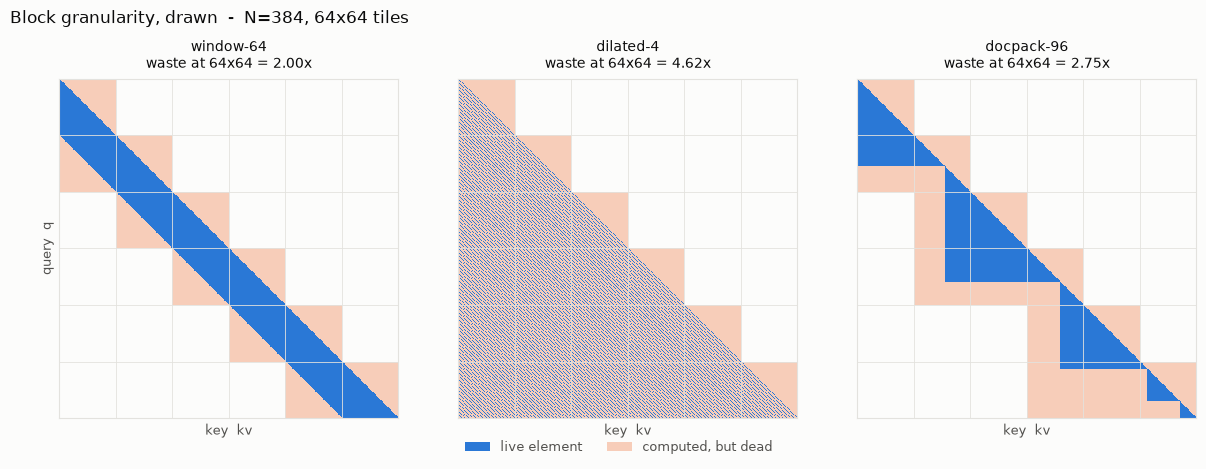

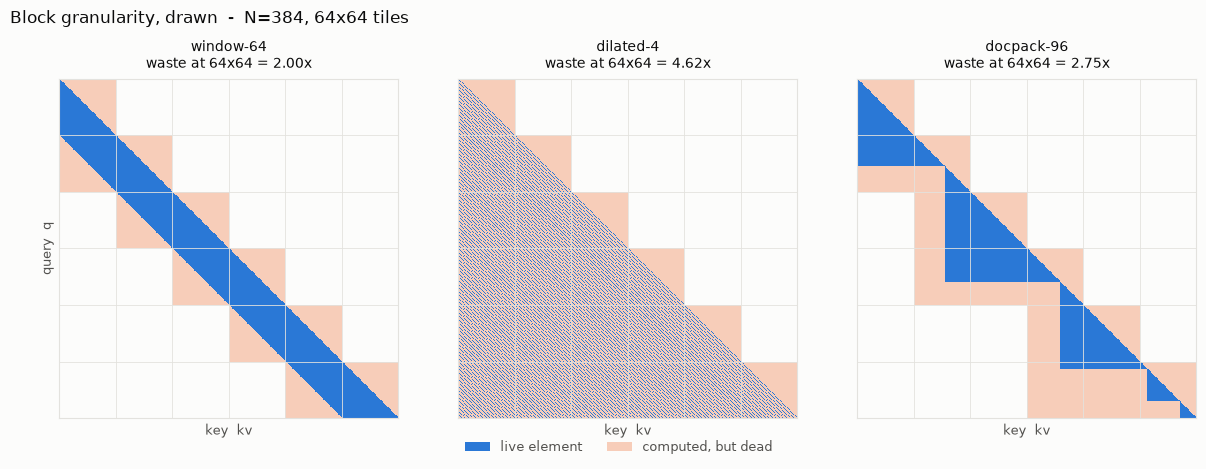

In [3]:
figures.fig_mask_gallery()

### Validation first

The sweep uses closed forms for `union_cols` and `live_count` to stay
$O(N^2/B_Q)$ instead of $O(N^2)$. Closed forms are exactly where a silent bug
would produce a beautiful, wrong result — so every one is checked against a
brute-forced dense mask, including the identity `cost(1,1) == live`.

In [4]:
import subprocess, sys
print(subprocess.run([sys.executable, "-m", "pytest", "-q"],
                     cwd="..", capture_output=True, text=True).stdout[-600:])

0ms.s.s...s.s.s...s.s.s...s.s.s...s [ 96%]
.s.s...s.s.s......                                                       [100%]



Row-blocks are sampled (512 evenly spaced) above 512 blocks. Measure that error
rather than assume it.

In [5]:
_ = sampling.run()

mask              BQ   A       sampled         exact   rel.err
window-128        32  32     2.611e+06     2.611e+06   0.0000%


window-128        16  16     2.349e+06      2.35e+06   0.0436%
docpack-512       32  32     5.087e+06     5.087e+06   0.0000%


docpack-512       16  16     4.657e+06     4.679e+06   0.4596%
dilated-8         32  32     1.345e+08     1.345e+08   0.0000%


dilated-8         16  16     1.343e+08     1.343e+08   0.0000%
sinks4+win256     32  32     5.197e+06     5.197e+06   0.0000%


sinks4+win256     16  16     4.677e+06     4.679e+06   0.0492%


local256+str8     32  32     1.345e+08     1.345e+08   0.0000%


local256+str8     16  16     1.343e+08     1.343e+08   0.0000%

worst relative error: 0.4596%


### The sweep

In [6]:
rows = granularity.run()
granularity.write_csv(rows)
granularity.print_table(rows, ns=[16384])   # the full 4K/16K/64K sweep is in results/results.csv

mask                  N  density   w@128    w@64    w@32    w@16  gain32  gain16
--------------------------------------------------------------------------------
causal            16384   50.00%    1.01    1.00    1.00    1.00    1.01    1.01

window-128        16384    0.78%    2.00    1.50    1.25    1.12    1.60    1.78

window-256        16384    1.55%    1.50    1.25    1.12    1.06    1.33    1.41

window-512        16384    3.08%    1.25    1.12    1.06    1.03    1.18    1.21

window-1024       16384    6.05%    1.12    1.06    1.03    1.02    1.09    1.11

window-4096       16384   21.88%    1.03    1.02    1.01    1.00    1.02    1.03

dilated-2         16384   25.00%    2.02    2.01    2.00    2.00    1.01    1.01

dilated-4         16384   12.50%    4.03    4.01    4.01    4.00    1.01    1.01

dilated-8         16384    6.25%    8.06    8.03    8.01    8.00    1.01    1.01

sinks4+win256     16384    1.57%    1.96    1.47    1.23    1.11    1.60    1.77

sinks4+win1024    

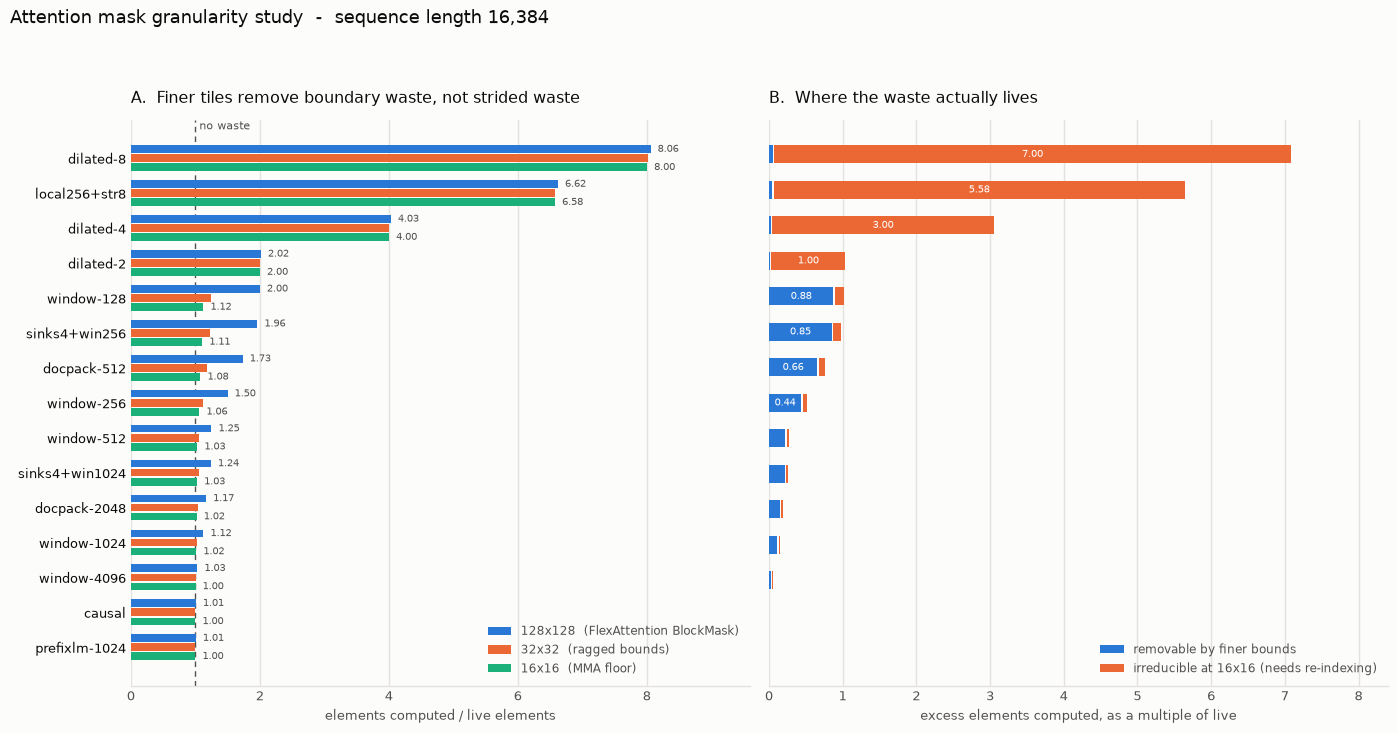

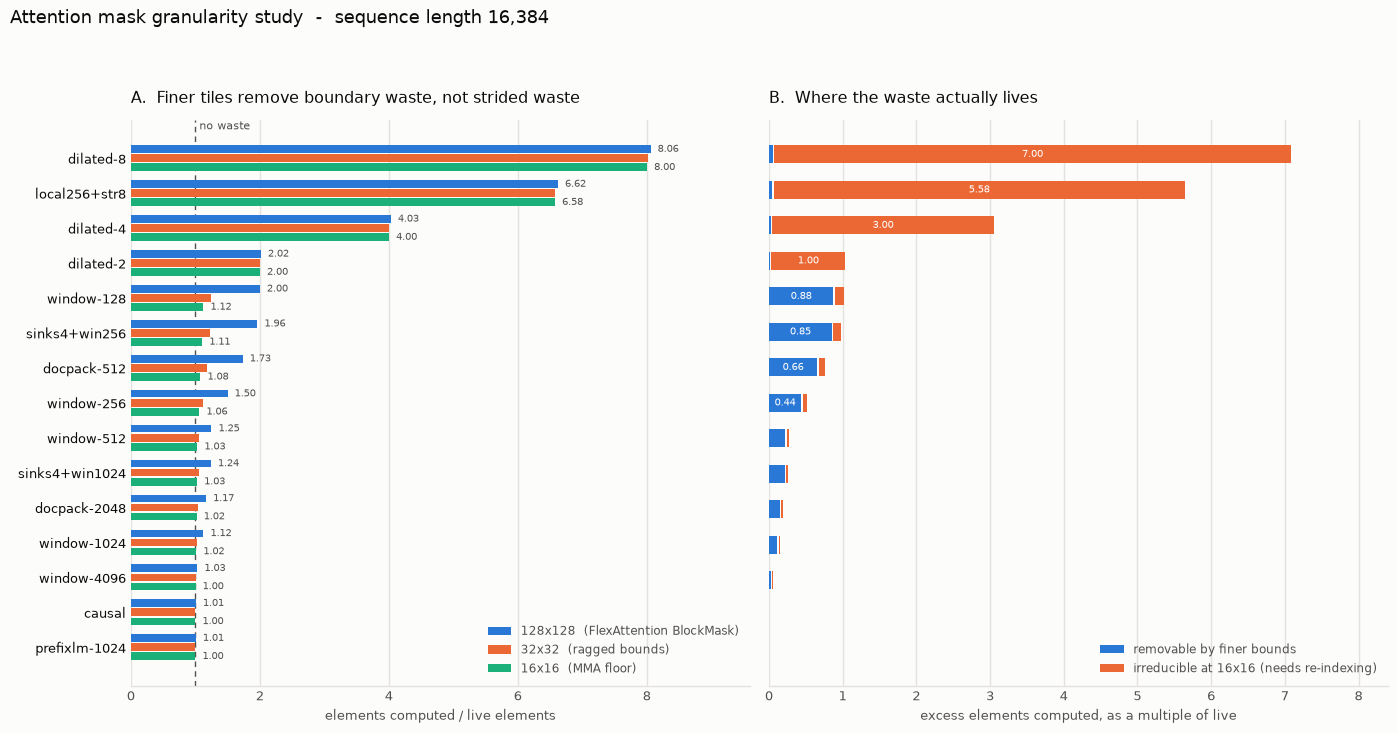

In [7]:
figures.fig_granularity(rows, n_show=16384)

### The finding — including a prediction that was wrong

Gain of ragged bounds over BlockMask, stable across N = 4K–64K:

| regime | gain @32×32 | gain @16×16 |
|---|---|---|
| window-128, sinks+win256 | **1.60×** | 1.78× |
| docpack-512 | 1.47× | 1.61× |
| window-256 | 1.33× | 1.41× |
| causal, prefix-LM, window ≥1024 | 1.00–1.01× | 1.03× |
| **dilated-2/4/8, local+strided** | **1.00–1.03×** | 1.03× |

**I predicted ~2× for dilated masks. The actual gain is nothing** — while
BlockMask simultaneously wastes 4× to 8× on them.

The reason is clean and it generalises:

> **With stride $s$ smaller than tile width $A$, every $A$-wide column tile
> contains a live element, so no tile is skippable at any granularity $\ge s$.**
> Tensor cores floor $A$ at 16, so any stride below 16 is *permanently invisible
> to pruning*, at any block size.

Panel B decomposes the excess into what finer bounds recover and what no pruning
can. For `dilated-8` the split is 0.06 / 7.00.

**Conclusion: the kill-test passes for the window and doc-packing regimes
(1.4–1.8×, comfortably over the 15% threshold) and fails everywhere else — and in
doing so relocates the interesting problem.** Pruning is the wrong verb for the
strided family.

## §3a — Correction: experiment 1 measures the wrong axis

A peer review flagged that the sweep above tests only **square** grains
(128², 64², 32², 16²), conflating two independent knobs. It does. Separating them
changes what §3 means, so the product grid is computed here rather than argued.

In [8]:
grid = granularity.product_grid(N=16384)
granularity.print_product_grid(grid)

mask              128x128   128x32   128x16   64x128    64x32    64x16   32x128    32x32    32x16   16x128    16x32    16x16
----------------------------------------------------------------------------------------------------------------------------
window-128           2.00     2.00     2.00     2.00     1.50     1.50     2.00     1.25     1.25     2.00     1.25     1.12
window-256           1.50     1.50     1.50     1.50     1.25     1.25     1.50     1.12     1.12     1.50     1.12     1.06
window-512           1.25     1.25     1.25     1.25     1.12     1.12     1.25     1.06     1.06     1.25     1.06     1.03
sinks4+win256        1.96     1.60     1.54     1.96     1.35     1.29     1.96     1.23     1.17     1.96     1.23     1.11
docpack-512          1.73     1.55     1.51     1.62     1.32     1.29     1.54     1.18     1.15     1.50     1.14     1.08
dilated-8            8.06     8.06     8.06     8.06     8.03     8.03     8.06     8.01     8.01     8.06     8.01     8.00


**For a mask whose per-row-block union is a single interval, refining *either*
axis alone buys exactly nothing.** The arithmetic is immediate once separated: the
union over $B_Q$ query rows of a width-$w$ window spans $w + B_Q - 1$ contiguous
columns, and the cost is that span rounded up to $A$. With $B_Q=128$ the span is
already $\approx 2w$, so tightening $A$ cannot help; with $A=128$ the rounding
swallows the gain from a small span. Only shrinking **both** reaches 1.12.

This matters because **shrinking $A$ is nearly free while shrinking $B_Q$ is
not** — small query tiles cost occupancy, MMA efficiency and per-tile softmax
statistics, which is exactly what this model does not price. The 1.4–1.8×
headline is therefore not a ragged-column result; it is a joint tile-shrink whose
expensive half is unpriced.

*(One refinement to the review's wording: it attributed the win to shrinking
$B_Q$. The data says otherwise — $B_Q$ alone at $A=128$ is also flat. Neither
axis alone does anything; the effect is strictly joint.)*

**What survives as genuine KV-axis content:** masks whose per-row-block union is
**multi-piece** — `sinks4+win256` (1.96 → 1.54, **1.28×**) and `docpack-512`
(1.73 → 1.51, **1.15×**) at production $B_Q=128$. Covering a union of disjoint
affine pieces is the real polyhedral operation, and it is worth 1.15–1.28×, not
1.6–1.8×.

Mechanism 1 (§4) is untouched by this — a class A permutation works at fixed tile
size and depends on shrinking nothing.

## §4 — Experiment 2: re-indexing

**Hypothesis:** the strided waste is untouchable by pruning but removable by a
**change of basis**. A strided live set is an affine lattice; the right transform
makes it contiguous, turning an 8×-wasteful mask into a dense small matmul.
A boolean block mask is a predicate over a *fixed* lattice and cannot express
this even in principle.

### Deriving the legal transform family

The search space is **not** all of $GL_2(\mathbb{Z})$. Attention reduces over
$kv$ at fixed $q$:

$$\mathrm{out}[q] = \sum_{kv} \mathrm{softmax}(S[q,kv])\, V[kv]$$

so a transform must not mix $q$ into the reduced axis in a way that breaks the
fibration over $q$. That leaves exactly:

| | transform | class |
|---|---|---|
| queries | $q' = \pi_q(q)$ | free — any permutation, undone on output |
| keys | $kv' = \pi_{kv}(kv)$ | **A** — $q$-independent relabelling |
| keys | $kv' = (kv - a\,q)/s$ | **B** — $q$-dependent shear / stride-fold |

**The cost split between the two classes turned out to be decisive:**

- **Class A** — the permuted K/V tensor is materialised **once per layer**,
  $O(N d)$ traffic, after which every tile is rectangular and contiguous.
  Effectively free.
- **Class B** — every tile needs a different slice of K/V, so the gather
  *cannot be amortised*: a $B_Q \times A$ tile touches $A + a(B_Q-1)$ distinct kv
  rows instead of $A$. FLOPs down, traffic up.

Computed exactly on a materialised $4096^2$ mask — no closed forms, no sampling.
Element count is asserted preserved by every transform.

In [9]:
print(inspect.getsource(transforms.make_residue_perm))
print(inspect.getsource(transforms.kv_per_tile))

def make_residue_perm(s):
    def f(M):
        """CLASS A: sort BOTH axes by (i mod s, i div s).

        A mask defined by kv == q (mod s) becomes block-diagonal: s independent
        dense sub-problems.  This is what LongNet does by hand, as a transform.
        """
        n = M.shape[0]
        order = np.argsort(np.arange(n) % s * n + np.arange(n) // s, kind="stable")
        return M[order][:, order], ("A", 0, 1)
    f.__name__ = f"residue-perm-{s}"
    return f

def kv_per_tile(kind, a, s, BQ, A):
    """Distinct physical kv rows a single BQ x A tile must touch.

    Class A: the permutation is applied to K/V once, so a tile reads A contiguous
    rows of the permuted tensor.  Class B: physical kv = j*s + a*q + const, so the
    tile spans the offset set {a*dq + s*dj}.
    """
    if kind == "A":
        return A
    dq = np.arange(BQ)[:, None]
    dj = np.arange(A)[None, :]
    return int(np.unique(a * dq - s * dj).size)



In [10]:
rx = reindex.run()
reindex.write_csv(rx)
reindex.print_table(rx)

N=4096, tile granularity 16x16, exact (no sampling)

mask            best transform     cls   waste   vs id  kv/tile  amort?
-----------------------------------------------------------------------
causal          identity             A    1.00   1.00x       16     yes
window-128      shear                B    1.00   1.12x       31      NO
window-256      shear                B    1.00   1.06x       31      NO
window-1024     shear                B    1.00   1.01x       31      NO
dilated-2       residue-perm-2       A    1.01   1.99x       16     yes
dilated-4       residue-perm-4       A    1.01   3.95x       16     yes
dilated-8       residue-perm-8       A    1.03   7.79x       16     yes
sinks4+win256   identity             A    1.11   1.00x       16     yes
local256+str8   residue-perm-8       A    1.24   3.49x       16     yes
docpack-512     identity             A    1.08   1.00x       16     yes

waste   = elements computed / live, after the transform (1.00 = perfect)
vs id   =

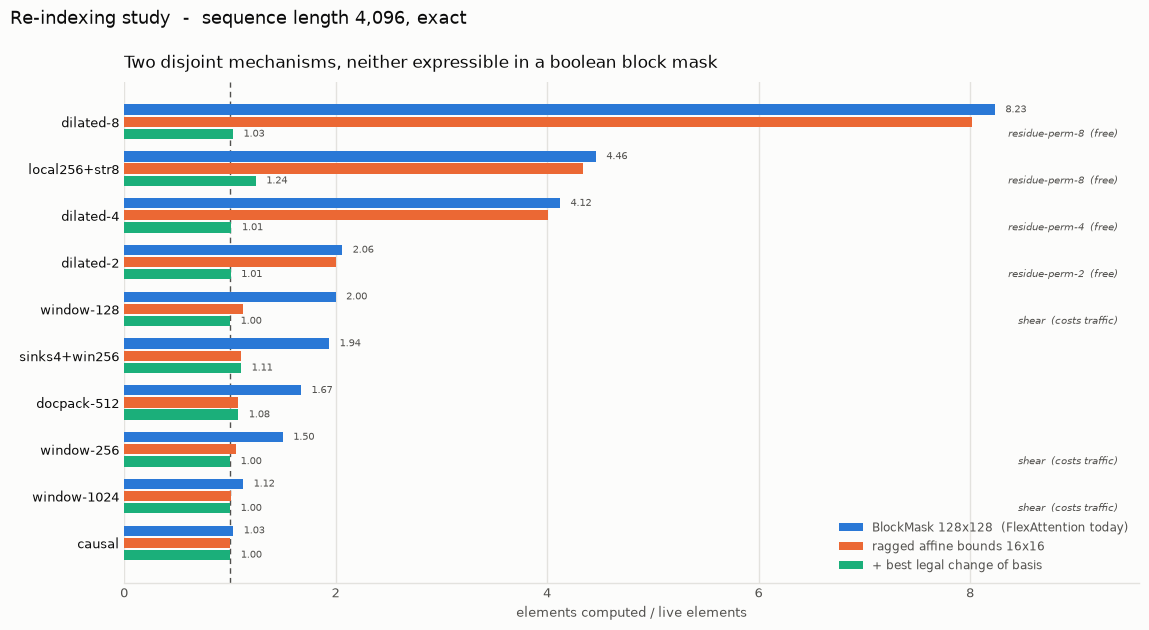

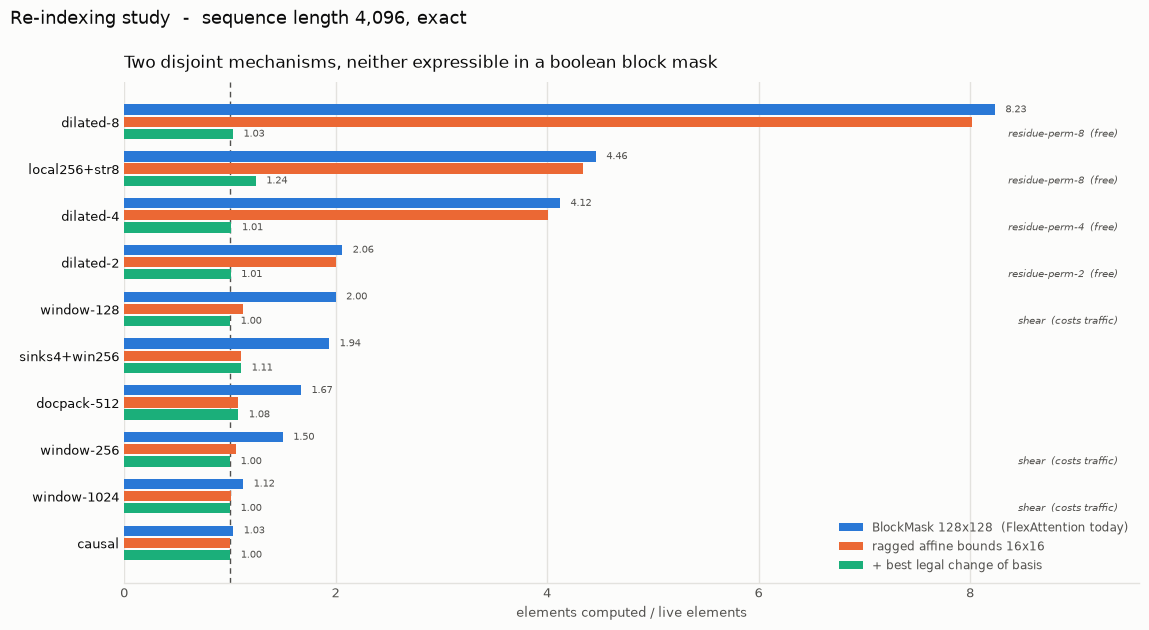

In [11]:
figures.fig_reindex(rows, rx, N=4096)

### What experiment 2 establishes

1. **The hypothesis holds, via the free class.** `dilated-8`'s 8× waste collapses
   to **1.03** under a *static, $q$-independent* permutation that keeps tiles
   contiguous — a 7.79× FLOP reduction. This is what LongNet does by hand for its
   own pattern; here it falls out as a derived transform.
2. **Shear is a trap.** It drives window masks to waste 1.00, but buys only
   **1.12× FLOPs while raising kv rows per tile from 16 to 31** (≈1.94× traffic),
   un-amortisable because each tile needs a different K/V slice. On a
   memory-bound kernel that is a **net loss**. Recorded as a negative result:
   *do not shear attention windows.*
3. **The two winning mechanisms are disjoint and composable**, each covering the
   other's blind spot:
   - strided / dilated → **Class A permutation (free), 2–8×**
   - small window, sinks, doc-packing → **ragged affine bounds, 1.4–1.8×**
   - causal, prefix-LM, large window → already optimal, 1.0×
4. **Composition is an open problem, and it shows.** `local256+str8` reaches only
   **1.24** — the residue permutation that fixes its strided component scatters
   its local-window component. A mask that is a *union* of sub-masks may need
   each term in its own basis.

## §5 — Experiment 3: composition

Experiment 2 left exactly one failure: `local256+str8` stalled at **1.24** under
any single transform, because the residue permutation that makes its strided
component dense *scatters* its local-window component. The two components want
different bases. So: give each its own.

### Why this is legal

Attention over a mask that is a **disjoint** union $M = P_1 \uplus P_2$ can be
computed as separate attentions over $P_1$ and $P_2$, merged with the standard
online-softmax (log-sum-exp) combine — the same mechanism flash-decoding and ring
attention already use to split the kv axis.

**Disjointness is essential**: an element counted in two parts would be
double-counted in the softmax denominator. Every decomposition below is peeled to
be disjoint by construction, and the union is asserted to reconstruct $M$ exactly.

### What it costs

Each extra part means one extra partial output + LSE pair per query. That is
**not** folded into the element counts — mixing traffic into a FLOP-proxy would
flatter the method. It is reported separately and sanity-checked against the work
saved.

### The search

A library of 12 shapes (bands, lattices, prefixes, full-causal), all subsets up
to size 3, peeled in a canonical order so each element lands in the most
tile-dense home available. Decompositions that do not reconstruct $M$ exactly are
rejected. **Every part is offered every class-A transform**, not just the one its
shape suggests — otherwise the $k{=}1$ row would be an artificially weak baseline
and the reported gain inflated. Class B (shear) is excluded throughout, since
experiment 2 showed it costs more traffic than it saves.

In [12]:
print(inspect.getsource(compose.evaluate))

def evaluate(M, combo, grain=GRAIN, inter=None):
    """Peel `combo` against M in canonical order.

    Returns (total elements computed, per-part detail), or None if the
    decomposition does not reconstruct M exactly. `inter` maps shape name to
    (shape & M), precomputed once per mask so the combination loop never
    rebuilds a dense shape.
    """
    combo = sorted(combo, key=lambda s: (shapes.ORDER[s.kind], -(s.p or 0)))
    N = M.shape[0]
    if inter is None:
        inter = {sh.name: sh.dense(N) & M for sh in combo}
    taken = np.zeros_like(M)
    parts = []
    for sh in combo:
        p = inter[sh.name] & ~taken
        if not p.any():
            return None                                   # redundant shape
        taken |= p
        parts.append((sh, p))
    if not np.array_equal(taken, M):
        return None                                       # incomplete cover
    total, detail = 0, []
    for sh, p in parts:
        e, basis = part_cost(p, grain)
        total

In [13]:
comp = compose.run()
print("\n" + "=" * 78)
compose.print_table(comp)


local256+str8   (all figures at N=4096)   best single basis 1.245  ->  decomposed 1.048  in 2 part(s)
      band-256     basis=identity           live=1,015,936  waste=1.062
      lattice-8    basis=residue-perm-8     live=  923,520  waste=1.031



local128+str4   (all figures at N=4096)   best single basis 1.090  ->  decomposed 1.038  in 2 part(s)
      band-128     basis=identity           live=  516,160  waste=1.125
      lattice-4    basis=residue-perm-4     live=1,970,112  waste=1.015



sinks4+win256   (all figures at N=4096)   best single basis 1.106  ->  decomposed 1.106  in 1 part(s)
      all          basis=identity           live=1,031,290  waste=1.106



dilated-8   (all figures at N=4096)   best single basis 1.029  ->  decomposed 1.029  in 1 part(s)
      lattice-8    basis=residue-perm-8     live=1,050,624  waste=1.029



window-128   (all figures at N=4096)   best single basis 1.125  ->  decomposed 1.125  in 1 part(s)
      band-128     basis=identity           live=  516,160  waste=1.125



causal   (all figures at N=4096)   best single basis 1.004  ->  decomposed 1.004  in 1 part(s)
      all          basis=identity           live=8,390,656  waste=1.004

mask              best single  decomposed  parts    gain  merge cost
------------------------------------------------------------------------------
local256+str8           1.245       1.048      2   1.19x       0.54%
local128+str4           1.090       1.038      2   1.05x       1.59%
sinks4+win256           1.106       1.106      1   1.00x           -
dilated-8               1.029       1.029      1   1.00x           -
window-128              1.125       1.125      1   1.00x           -
causal                  1.004       1.004      1   1.00x           -

best single / decomposed are waste at 16x16, both verified at N=4096
merge cost = LSE-combine overhead as a fraction of the work saved (order-of-magnitude)


### What experiment 3 establishes

1. **The open failure closes.** `local256+str8` goes **1.245 → 1.048** — split
   into `band-256` in the identity basis (waste 1.062) and `lattice-8` under
   `residue-perm-8` (waste 1.031). Against BlockMask's 4.46 that is now a **4.26×**
   total reduction, of which Class A alone supplied 3.6× and composition the
   final 1.19×. Proportion matters here: composition is the smaller of the two
   effects, and should be written up as the closer, not the headline.
2. **The merge is cheap.** The LSE-combine overhead comes to ~0.5% of the work it
   buys on `local256+str8` (order-of-magnitude estimate, traffic-vs-FLOPs, not a
   measurement). It is not what limits this.
3. **Composition helps only genuine unions.** Four of six masks gain nothing.
   `sinks4+win256` is the instructive negative: splitting off its 4-wide sink
   prefix costs *more* than it saves, because 4 columns still occupy a full
   16-wide tile. **A sub-mask narrower than the MMA granularity should never be
   peeled off** — a rule the eventual cost model needs to encode.
4. **This is now a three-mechanism space**, and which one applies is a property of
   the predicate:

   | mask structure | mechanism | typical gain vs BlockMask |
   |---|---|---|
   | stride < 16 | class A permutation (free) | 2–8× |
   | small window, unaligned boundaries | ragged affine bounds | 1.4–1.8× |
   | union of differently-structured families | disjoint split + LSE merge | +1.05–1.19× |
   | causal, prefix-LM, large window | none — already optimal | 1.0× |

   Selecting among them automatically, from the predicate alone, is the compiler
   contribution. This table is its specification.

## §6 — Where the project stands

**Established** (analytically, exactly, validated against brute force):

- BlockMask's partial-block waste is 1.4–1.8× for small windows and unaligned
  document packing, and ~1.0× for causal / prefix-LM / large windows.
- For stride < 16 that waste is 4–8× and is **unreachable by any pruning**.
- A free, $q$-independent permutation removes essentially all of it.
- A $q$-dependent shear removes window waste but costs more traffic than it saves.
- Masks that are unions of differently-structured families can be split into
  disjoint parts, each in its own basis, and merged with online softmax; this
  closes the last mask that resisted a single transform (1.245 → 1.048) at ~0.5%
  merge overhead. It does nothing for masks that are not such unions, and must
  never peel off a sub-mask narrower than the MMA granularity.

**Not established — nothing here has touched a GPU:**

- **These are element counts, not time.** Smaller tiles cost occupancy and MMA
  efficiency; a 1.6× element reduction at 32×32 could land well under 1.6×
  wall-clock, or negative. This is the single largest gap.
- The Class A permutation's one-time cost, and its interaction with KV-cache
  layout during decode, is argued rather than measured.
- The Class B traffic model counts distinct kv rows per tile and ignores cache
  reuse across tiles, so it likely *overstates* the shear penalty. The conclusion
  (net loss) is robust to that; the magnitude is not.

**Novelty position, stated honestly:** re-indexing for strided attention is not
new *per pattern* — LongNet and Sparse Transformer hand-implement exactly this.
The claim that survives is **deriving the transform automatically from an
arbitrary predicate**, plus the characterisation of which mechanism applies
where. Narrower than "faster attention", and should be written as such.

### Next, ranked by information per unit cost

1. ~~**Composition search**~~ — **done, §5.** `local256+str8` 1.245 → 1.048.
2. **Widen the transform family** — general $(a, s)$ grid, plus bandwidth-reducing
   permutations for irregular masks like doc-packing.
3. **Hand-written Triton kernel for one Class A case** (`dilated-8` +
   `residue-perm-8`). **This is now the critical path.** The real go/no-go gate:
   it converts a 7.79× element reduction into a wall-clock number, and is the
   first result that could falsify the whole line. Everything above it is
   analysis; nothing further should be modelled before it is measured.
4. **Then the compiler** — predicate → domain → transform selection → Triton.
5. **A cost model for transform selection.** §4's table is the training data, and
   this is the piece that makes the work a compiler contribution rather than a
   collection of kernels.

**Standing risk:** FlexAttention is actively developed and could narrow the
partial-block gap itself. That would eliminate mechanism 2 but not mechanism 1,
which is structurally outside what a boolean block mask can represent.